In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
dpdbo = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05.pkl")
dpdbswing = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05Swing.pkl")
dpdbnet = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05net.pkl")
dpdbio = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05io.pkl")
dpdbawt = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05awt.pkl")
dpdbargouml = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05argo.pkl")
dpdbant = pd.read_pickle("drive/MyDrive/Pattern-Vision/DBPattenV05ant.pkl")
dpdb=pd.concat([dpdbo,dpdbswing,dpdbnet,dpdbio,dpdbawt,dpdbargouml,dpdbant])

In [ ]:
import matplotlib.pyplot as plt
import itertools
import numpy as np
from sklearn import svm, datasets
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier

In [ ]:
def flatten_list(_2d_list):
    flat_list = []
    for element in _2d_list:
        if type(element) is list:
            for item in element:
                flat_list.append(item)
        else:
            flat_list.append(element)
    return flat_list

In [ ]:
dpdb.sample(frac=1)

,Metrics,Patterns
86,"[[0, 0, 0, 121, 2, 0, 82, 0.9217687, 49, 0, 46...",Strategy
82,"[[5, 3, 2, 10, 1, 0, 17, 0.5, 2, 1, 2, 0, 0, 0...",Flyweight
47,"[[5, 0, 5, 2, 3, 0, 3, 0.0, 2, 0, 1, 0, 1, 0, ...",Strategy
10,"[[2, 0, 2, 78, 1, 0, 39, 0.97096777, 31, 0, 23...",Strategy
36,"[[16, 7, 9, 9, 1, 0, 8, 0.6428572, 7, 0, 5, 1,...",Strategy
...,...,...
16,"[[2, 0, 2, 62, 6, 0, 38, 0.8961039, 33, 1, 25,...",Strategy
17,"[[5, 1, 4, 8, 3, 0, 13, 0.14285715, 7, 0, 7, 0...",Decorator
65,"[[3, 1, 2, 9, 3, 0, 8, 0.8333333, 6, 1, 1, 0, ...",Flyweight
25,"[[2, 0, 2, 33, 2, 0, 25, 0.9375, 16, 0, 9, 0, ...",State


In [ ]:
import tensorflow as tf
dpdb=dpdb.sample(frac=1).reset_index()

In [ ]:
dpdb=dpdb.drop('index',axis=1)
dpdb=dpdb[dpdb.Metrics.map(len)>=1]
dpdb

,Metrics,Patterns
0,"[[15, 1, 14, 53, 8, 0, 59, 0.8636363, 11, 0, 8...",Flyweight
1,"[[1, 0, 1, 4, 2, 0, 6, 0.6666667, 3, 0, 3, 0, ...",Strategy
2,"[[3, 0, 3, 42, 34, 1, 16, 0.90909094, 11, 0, 1...",Flyweight
3,"[[12, 2, 10, 576, 6, 32, 275, 0.98550725, 180,...",Flyweight
4,"[[3, 0, 3, 71, 4, 0, 41, 0.95454544, 22, 0, 2,...",State
...,...,...
549,"[[0, 0, 0, 2, 2, 0, 1, 0.5, 2, 0, 1, 0, 0, 1, ...",Decorator
550,"[[5, 2, 3, 11, 3, 0, 18, 0.6666667, 3, 1, 2, 0...",Flyweight
551,"[[5, 2, 3, 9, 3, 0, 11, 0.6666667, 3, 1, 2, 0,...",Flyweight
552,"[[4, 2, 2, 3, 3, 0, 4, 0.6666667, 3, 1, 1, 0, ...",Flyweight


In [ ]:
#for i,sample in dpdb.items()
import math
for i, sample in dpdb["Metrics"].items():
  for item in sample:
    for j in range(len(item)):
      if  math.isnan(item[j]):
        item[j]=0


In [ ]:
dpdb=dpdb.loc[dpdb["Patterns"]!="Mediator"]
dpdb["Patterns"].value_counts()

Flyweight                    196
Strategy                     167
Decorator                     41
State                         35
Adapter                       30
Singleton                     27
Template_Method               25
Chain_of_Responsibilities     24
Proxy                          4
Visitor                        3
Observer                       2
Name: Patterns, dtype: int64

In [ ]:
def permute2(lista):
  p=lista[1]
  lista[1]=lista[2]
  lista[2]=p
  return lista

In [ ]:
import numpy as np

def permute_vector(vector):
    return np.random.permutation(vector)

def permute_dataset(data):
    permuted_data = {
        "Metrics": [],
        "Patterns": []
    }
    for metrics, label in zip(data["Metrics"], data["Patterns"]):
      permuted_data["Metrics"].append(permute2(metrics))
      permuted_data["Patterns"].append(label)
      for i in range(2):
        arr = np.array(metrics)
        shifted_arr = np.roll(arr, -i+1, axis=0)
        shifted_list = shifted_arr.tolist()
        permuted_data["Metrics"].append(shifted_list)
        permuted_data["Patterns"].append(label)
        permuted_data["Metrics"].append(permute2(shifted_list))
        permuted_data["Patterns"].append(label)
    return permuted_data


permuted_data = pd.DataFrame(permute_dataset(dpdb))

print(permuted_data)
print(dpdb)
dpdb= pd.concat([dpdb,permuted_data], ignore_index=True,axis=0)

                                                Metrics  \
0     [[15, 1, 14, 53, 8, 0, 59, 0.8636363, 11, 0, 8...   
1     [[7.6159874586206895, 7.6159874586206895, 7.61...   
2     [[7.6159874586206895, 7.6159874586206895, 7.61...   
3     [[15.0, 1.0, 14.0, 53.0, 8.0, 0.0, 59.0, 0.863...   
4     [[15.0, 1.0, 14.0, 53.0, 8.0, 0.0, 59.0, 0.863...   
...                                                 ...   
2765  [[2, 0, 2, 78, 1, 0, 39, 0.97096777, 31, 0, 23...   
2766  [[0.0, 0.0, 0.0, 5.0, 1.0, 0.0, 0.0, 0.0, 5.0,...   
2767  [[0.0, 0.0, 0.0, 5.0, 1.0, 0.0, 0.0, 0.0, 5.0,...   
2768  [[2.0, 0.0, 2.0, 78.0, 1.0, 0.0, 39.0, 0.97096...   
2769  [[2.0, 0.0, 2.0, 78.0, 1.0, 0.0, 39.0, 0.97096...   

                       Patterns  
0                     Flyweight  
1                     Flyweight  
2                     Flyweight  
3                     Flyweight  
4                     Flyweight  
...                         ...  
2765  Chain_of_Responsibilities  
2766  Chain_of_Resp

In [ ]:
dpdb["Metrics"]

0       [[15, 1, 14, 53, 8, 0, 59, 0.8636363, 11, 0, 8...
1       [[1, 0, 1, 4, 2, 0, 6, 0.6666667, 3, 0, 3, 0, ...
2       [[3, 0, 3, 42, 34, 1, 16, 0.90909094, 11, 0, 1...
3       [[12, 2, 10, 576, 6, 32, 275, 0.98550725, 180,...
4       [[3, 0, 3, 71, 4, 0, 41, 0.95454544, 22, 0, 2,...
                              ...                        
3319    [[2, 0, 2, 78, 1, 0, 39, 0.97096777, 31, 0, 23...
3320    [[0.0, 0.0, 0.0, 5.0, 1.0, 0.0, 0.0, 0.0, 5.0,...
3321    [[0.0, 0.0, 0.0, 5.0, 1.0, 0.0, 0.0, 0.0, 5.0,...
3322    [[2.0, 0.0, 2.0, 78.0, 1.0, 0.0, 39.0, 0.97096...
3323    [[2.0, 0.0, 2.0, 78.0, 1.0, 0.0, 39.0, 0.97096...
Name: Metrics, Length: 3324, dtype: object

In [ ]:
Unique_labels=dpdb["Patterns"].unique()

In [ ]:
class_names=Unique_labels

In [ ]:
labels=dpdb["Patterns"]

In [ ]:
labels

0                       Flyweight
1                        Strategy
2                       Flyweight
3                       Flyweight
4                           State
                  ...            
3319    Chain_of_Responsibilities
3320    Chain_of_Responsibilities
3321    Chain_of_Responsibilities
3322    Chain_of_Responsibilities
3323    Chain_of_Responsibilities
Name: Patterns, Length: 3324, dtype: object

In [ ]:
bool_label=[label==Unique_labels for label in labels]

In [ ]:
one_hot_label=np.array([bool.astype(int)for bool in bool_label])

In [ ]:
one_hot_label[:3]


array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [ ]:
dpdbwith0=dpdb["Metrics"]
max_sample_length = max([len(sample) for sample in dpdbwith0])
zeros_list = [0] * 29

for i, sample in dpdbwith0.items():

    if len(sample) != max_sample_length:
      for j in  range(max_sample_length-len(sample)):
        dpdbwith0[i].append(zeros_list)

In [ ]:
max_sample_length

3

In [ ]:
dpdbwith0=dpdbwith0.apply(lambda row :flatten_list(row))
dpdbwith0

0       [15, 1, 14, 53, 8, 0, 59, 0.8636363, 11, 0, 8,...
1       [1, 0, 1, 4, 2, 0, 6, 0.6666667, 3, 0, 3, 0, 0...
2       [3, 0, 3, 42, 34, 1, 16, 0.90909094, 11, 0, 10...
3       [12, 2, 10, 576, 6, 32, 275, 0.98550725, 180, ...
4       [3, 0, 3, 71, 4, 0, 41, 0.95454544, 22, 0, 2, ...
                              ...                        
3319    [2, 0, 2, 78, 1, 0, 39, 0.97096777, 31, 0, 23,...
3320    [0.0, 0.0, 0.0, 5.0, 1.0, 0.0, 0.0, 0.0, 5.0, ...
3321    [0.0, 0.0, 0.0, 5.0, 1.0, 0.0, 0.0, 0.0, 5.0, ...
3322    [2.0, 0.0, 2.0, 78.0, 1.0, 0.0, 39.0, 0.970967...
3323    [2.0, 0.0, 2.0, 78.0, 1.0, 0.0, 39.0, 0.970967...
Name: Metrics, Length: 3324, dtype: object

In [ ]:
reformatted_df = dpdbwith0.apply(pd.Series)

In [ ]:
reformatted_df.shape

(3324, 87)

In [ ]:
reformatted_df= np.asarray(reformatted_df).astype('float32')

In [ ]:
LabelsN=[]
for i,sample in enumerate(one_hot_label):
  for j,k in enumerate(sample):
    if sample[j]==1:
      LabelsN.append(j+1)
      break;
LabelsN=np.array(LabelsN)

In [ ]:
scores=[]
precision_scores = []
recall_scores = []
f1_scores = []

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(data_x, data_y):
    k_fold = KFold(5, shuffle=True, random_state=1)

    predicted_targets = np.array([])
    actual_targets = np.array([])

    for train_ix, test_ix in k_fold.split(data_x):
        train_x, train_y, test_x, test_y = data_x[train_ix], data_y[train_ix], data_x[test_ix], data_y[test_ix]


        classifier = RandomForestClassifier().fit(train_x, train_y)
        scores.append(classifier.score(test_x,test_y))

        predicted_labels = classifier.predict(test_x)
        precision_scores.append(precision_score(test_y, predicted_labels, average=None))
        recall_scores.append(recall_score(test_y, predicted_labels, average=None))
        f1_scores.append(f1_score(test_y, predicted_labels, average=None))

        predicted_targets = np.append(predicted_targets, predicted_labels)
        actual_targets = np.append(actual_targets, test_y)

    return predicted_targets, actual_targets

In [ ]:
def plot_confusion_matrix(predicted_labels_list, y_test_list):
    cnf_matrix = confusion_matrix(y_test_list, predicted_labels_list)
    np.set_printoptions(precision=2)

    # Plot non-normalized confusion matrix
    plt.figure()
    generate_confusion_matrix(cnf_matrix, classes=class_names, title='Confusion matrix, without normalization')
    plt.show()

    # Plot normalized confusion matrix
    plt.figure()
    generate_confusion_matrix(cnf_matrix, classes=class_names, normalize=True, title='Normalized confusion matrix')
    plt.show()


In [ ]:
dpdb["Patterns"].value_counts()

Flyweight                    1176
Strategy                     1002
Decorator                     246
State                         210
Adapter                       180
Singleton                     162
Template_Method               150
Chain_of_Responsibilities     144
Proxy                          24
Visitor                        18
Observer                       12
Name: Patterns, dtype: int64

In [ ]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

def generate_confusion_matrix(cnf_matrix, classes, normalize=False, title='Confusion matrix'):
    if normalize:
        cnf_matrix = cnf_matrix.astype('float') / cnf_matrix.sum(axis=1)[:, np.newaxis] * 100
        print("Normalized confusion matrix")
        fmt = '.2f'
    else:
        print('Confusion matrix, without normalization')
        fmt = 'd'

    f = plt.figure()
    f.set_figwidth(12)
    f.set_figheight(10)
    plt.imshow(cnf_matrix, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cnf_matrix.max() / 2.

    for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
        value = format(cnf_matrix[i, j], fmt)
        if normalize:
            value += '%'
        plt.text(j, i, value, horizontalalignment="center",
                 color="white" if cnf_matrix[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    return cnf_matrix


Confusion matrix, without normalization


<Figure size 640x480 with 0 Axes>

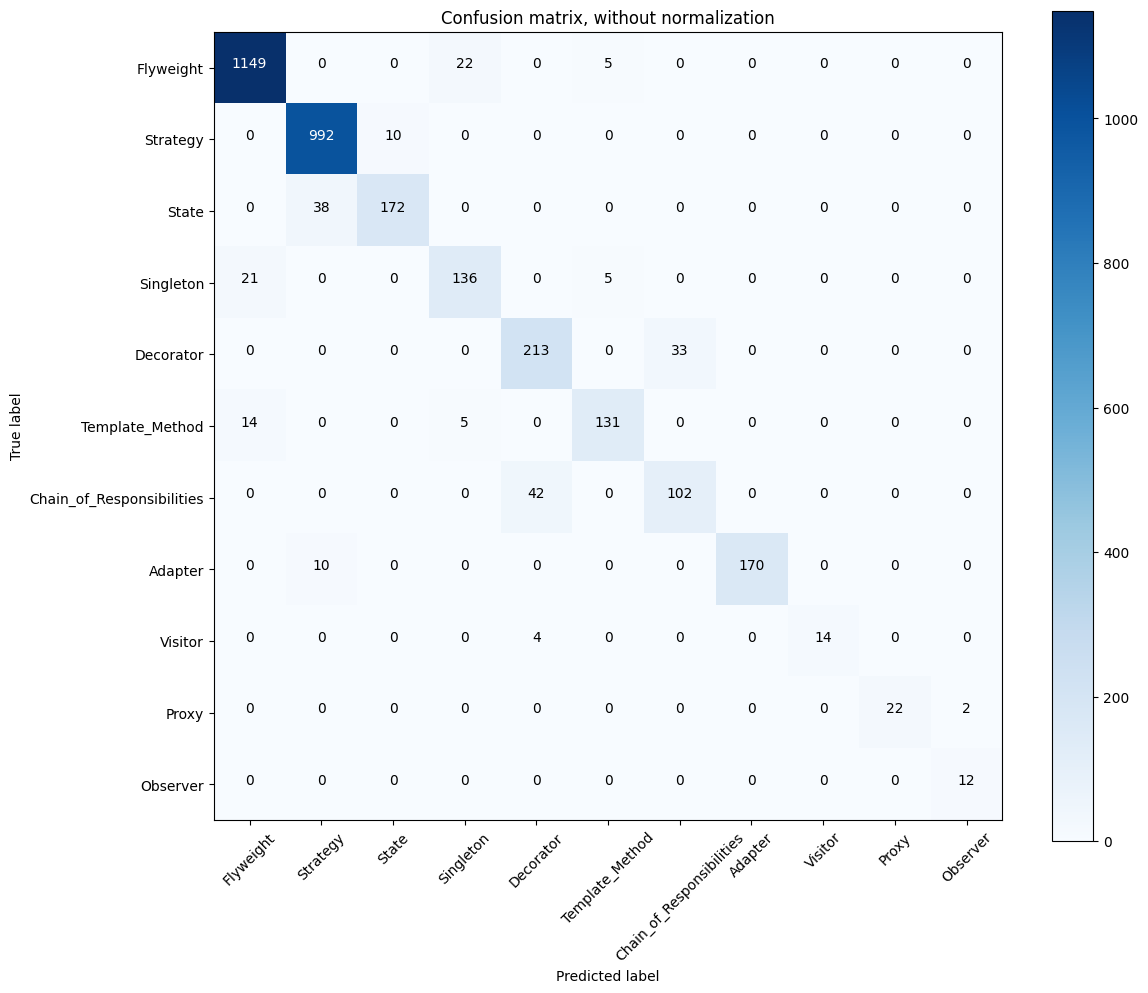

Normalized confusion matrix


<Figure size 640x480 with 0 Axes>

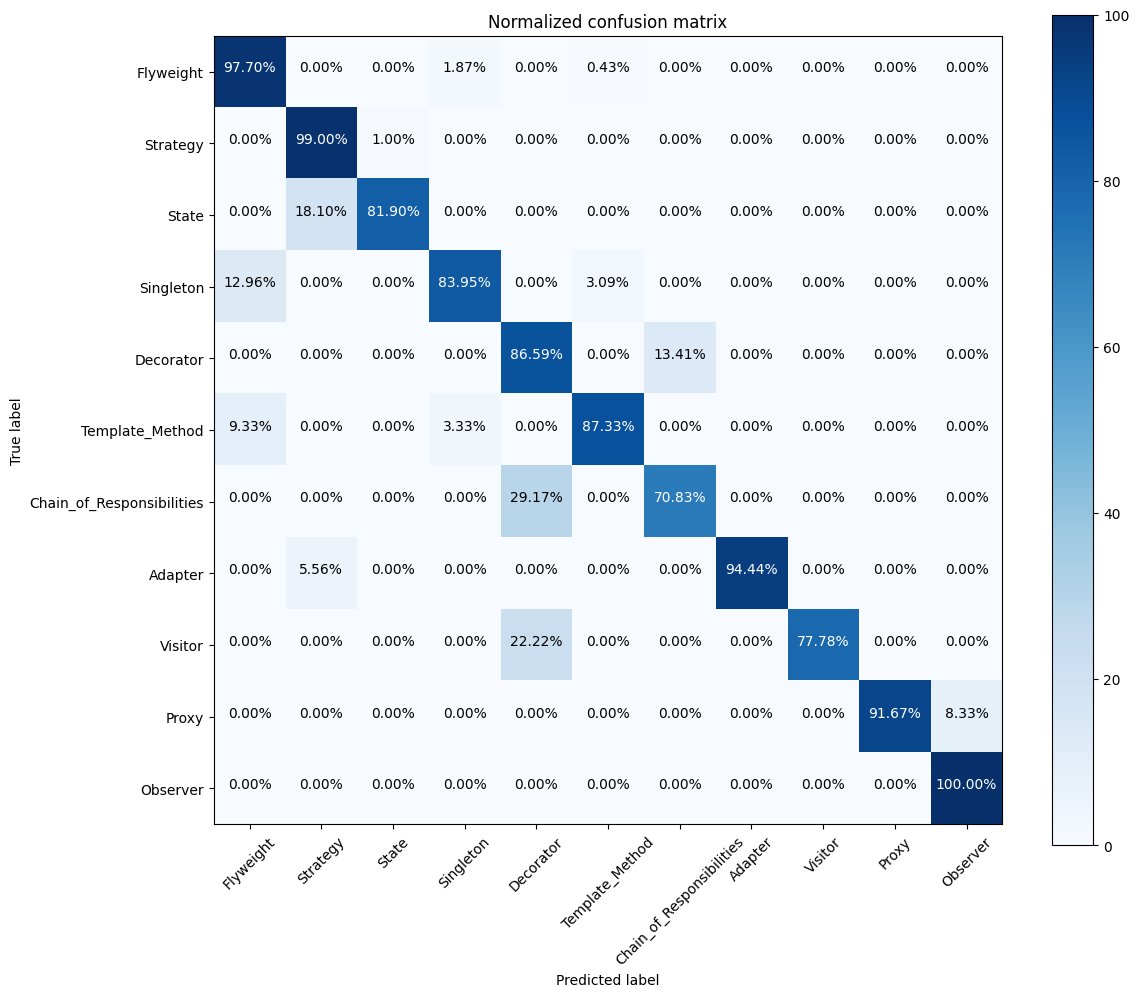

In [ ]:
predicted_target, actual_target = evaluate_model(reformatted_df, LabelsN)
plot_confusion_matrix(predicted_target, actual_target)

In [ ]:
accuracy = np.mean(scores)
precision = np.mean(precision_scores, axis=0)
recall = np.mean(recall_scores, axis=0)
f1 = np.mean(f1_scores, axis=0)
accuracy,precision,recall,f1

(0.9365196122837215,
 array([0.97, 0.95, 0.95, 0.84, 0.82, 0.94, 0.75, 1.  , 1.  , 1.  , 0.9 ]),
 array([0.98, 0.99, 0.82, 0.84, 0.86, 0.88, 0.71, 0.95, 0.84, 0.92, 1.  ]),
 array([0.97, 0.97, 0.88, 0.84, 0.84, 0.9 , 0.73, 0.97, 0.9 , 0.95, 0.93]))